### Imports

In [1]:
import os
import sys
import random

In [2]:
import time
import json

In [3]:
# import warnings
# warnings.simplefilter("always")

In [4]:
import numpy as np

In [5]:
# from collections import Counter

In [6]:
import torch
from torch import nn
from torch.nn import functional

In [7]:
from torch.utils.data import Dataset

In [8]:
# import torchvision
import torchvision.transforms as transforms

In [9]:
# Weizmann dataset
from src.load_weizmann import download_weizmann_masks
from src.load_weizmann import PERSONS, ACTIONS, DESCRIPTIONS

In [10]:
# train and validation loops
from src.loops import train_loop, val_loop

In [11]:
from tqdm import tqdm
from datetime import datetime

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.style.use('dark_background')
%matplotlib inline
# %config InlineBackend.figure_format = 'retina'

# Notebook "Weizmann Dataset Recognition" settings

In [13]:
today_date = datetime.today().strftime('%d-%m-%Y_%H-%M')  # date for a results folder name
today_date

'09-05-2025_19-23'

In [14]:
# Define all necessery variables for that notebook
VARIABLES = {
    # FILEPATHES
    'data_path': 'data/',  # folder which will be created (if not exists) to load/store Weizmann dataset
    'results_path': f'results/exp_{today_date}',  # filepath to save results!
        
    # DATASET OF SUBSEQUENCES SETTINGS
    'sequence_len': 3,  # each video will be splitted into subsequences of this length
    'skip_between_frames': 2,  # it is a skip between timesteps in sequences
    'augmentation_flip': True,  # if True uses a horizontal flip to make a dataset twice as large

    'center_silhouettes': True,  # if True - every silhouette placed in a center of a frame!
    'exclude_cutted_silhouettes': True,
        # Comment: Some frames are cutted because for some actions a person appears within 
        #          a frame and goes to the opposite boundary! 
        # Criterias to exclude a frame because of a part of a silhouette is out of frame:
        #     1. one of boundaries of a silhouette bounding box coincides with a boundary of a frame;
        #     2. if 1^st criteria satisfied and a width of a silhouette bounding box is less than some value
    'weighted_classes': True,

    # NETWORK
    'feature_dim': 16,
    'hidden_dim': 16,  # see Subsection 3.1.
    
    # NEURAL NETWORK LEARNING
    'DEVICE': 'cpu',  # if `cuda` - we will check if it is available
    'train_batch_size': 10,  # batch sizes for training
    'val_batch_size': 20,
    'adam_lr': 0.001,  # learning rate for Adam optimizer
    'number_of_epochs': 10,  # number of epochs to train
}

In [15]:
RESULTS_FOLDER = VARIABLES['results_path']

if not os.path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)

In [16]:
RESULTS_FOLDER

'results/exp_09-05-2025_19-23'

In [17]:
# save experiment conditions (VARIABLES dictionary)
with open(f'{RESULTS_FOLDER}/conditions.json', 'w', encoding ='utf8') as json_file:
    json.dump(VARIABLES, json_file, ensure_ascii = True)

# 1. Dataset preparation

## Load data

> The extracted masks obtained by background subtraction: the file (Matlab 7 format, ~1700KB) contains both the original masks as well as the aligned ones (that were the actual inputs to our algorithm).

<span style="color:red">**Comment:**</span> All masks are of the shape $64 \times 64$.

In [18]:
WEIZMANN_DIR = VARIABLES['data_path']

#### Load masks

In [19]:
# uncomment to download masks:
download_weizmann_masks(dest=WEIZMANN_DIR)

Saving masks for `bend` as .npy to `data/bend_masks`... Done!
Saving masks for `jack` as .npy to `data/jack_masks`... Done!
Saving masks for `jump` as .npy to `data/jump_masks`... Done!
Saving masks for `pjump` as .npy to `data/pjump_masks`... Done!
Saving masks for `run` as .npy to `data/run_masks`... Done!
Saving masks for `side` as .npy to `data/side_masks`... Done!
Saving masks for `skip` as .npy to `data/skip_masks`... Done!
Saving masks for `walk` as .npy to `data/walk_masks`... Done!
Saving masks for `wave1` as .npy to `data/wave1_masks`... Done!
Saving masks for `wave2` as .npy to `data/wave2_masks`... Done!


#### Actions labels

In [20]:
NUM_ACTIONS = len(ACTIONS)

In [21]:
ID_TO_ACTION = {idx: act for idx, act in enumerate(ACTIONS)}
ACTION_TO_ID = {act: idx for idx, act in ID_TO_ACTION.items()}
ACTION_TO_ID

{'bend': 0,
 'jack': 1,
 'jump': 2,
 'pjump': 3,
 'run': 4,
 'side': 5,
 'skip': 6,
 'walk': 7,
 'wave1': 8,
 'wave2': 9}

In [87]:
# save id to action dict!
with open(f'{RESULTS_FOLDER}/id2action.json', 'w', encoding ='utf8') as json_file:
    json.dump(ID_TO_ACTION, json_file, ensure_ascii = True)

## 1.1. Train and Test data 

For each action we will select `N_PER_ACTION_TRAIN` videos in a train set. Other -- in validation.

<span style="color:red">**Comment:**</span> Do we need to select videos for each action by persons or not?

In [23]:
N_PER_ACTION_TRAIN = 6  # number of videos (0 < N < 9) of each action for the train set!

In [24]:
# we need to select 6 videos of each action for train 
np.random.seed(78)  # for reproducibility!

seed_for_each_action = np.random.randint(
    low=0, high=100, 
    size=len(ACTIONS), 
)  # random seed to select n_train out of 9 videos for each action

n_train = N_PER_ACTION_TRAIN
# if n_train == 6:
#     RATIOS: test / train = 1 / 2, train / all = 2 / 3

n_files_of_each_action = 9  # all files in each action folder

all_files = []
all_train_files = []  # files which will be used as train data
all_test_files = []   # files which will be used as test data

for ind, act_this in enumerate(ACTIONS):
    dir_this = os.path.join(WEIZMANN_DIR, f'{act_this}_masks')
    lisdir_this = [fn for fn in os.listdir(dir_this) if fn[-3:] == 'npy']
    
    np.random.seed(seed_for_each_action[ind])  # seed for the action to select 6 files
    train_ids = np.random.choice(n_files_of_each_action, n_train, replace=False)
    
    for ind_file, filepath in enumerate(lisdir_this):
        all_files.append(os.path.join(dir_this, filepath))
        
        if ind_file in train_ids:
            all_train_files.append(os.path.join(dir_this, filepath))
        else:
            all_test_files.append(os.path.join(dir_this, filepath))

In [25]:
print(f'Train files: {len(all_train_files)}')
print(f'Test  files: {len(all_test_files)}')

Train files: 60
Test  files: 30


In [88]:
# saving files with filenames for train/test sets
with open(f'{RESULTS_FOLDER}/train_files.txt', 'w') as file:
    for filepath_this in all_train_files:
        file.write(f'{filepath_this}\n')

with open(f'{RESULTS_FOLDER}/test_files.txt', 'w') as file:
    for filepath_this in all_test_files:
        file.write(f'{filepath_this}\n')

In [27]:
print(f'All files: {len(all_files)}')

All files: 90


## 1.2. Data sequencing 

Each video will be divided into numbers of sub-sequences by sequentially extracting `SEQ_LEN` frames for each sub-sequence with a frame interval of `SKIP`.

In [28]:
SEQ_LEN = VARIABLES['sequence_len']
SKIP = VARIABLES['skip_between_frames']  # it is a skip between timesteps in sequences

## 1.3. Dataset construction

#### <span style="color:red">Data augmentation</span>

The data augmentation (horizontally flip) can be performed for videos! It will make dataset of sub-sequences as twice as large!

In [29]:
INIT_MASK_SIZE = 64  # each loaded mask is of the shape 64x64

### 1.3.1. Centering of silhouettes

In [30]:
# we can center each silhouette before forming a subsequence!
CENTERING = VARIABLES['center_silhouettes']

# for silhouette detection (needed if CENTERING == True)
BRIGHTNESS_LIM = 0.05  # value from 0 to 1 to build strickt boundaries of a silhouette
# Comment: in fact it is a hyperparameter
CENTERED_MASK_SIZE = INIT_MASK_SIZE

# We add 0's padding to a silhouette rectangle to make a square of the following size!

#### Example of a silhouette centering (if `CENTERING == True`)

This process performed within a dataset (see <span style="color:red">Data class</span> below).

In [31]:
# all actions
print(*ACTIONS)

bend jack jump pjump run side skip walk wave1 wave2


In [32]:
# all persons
print(*PERSONS)

daria denis eli ido ira lena lyova moshe shahar


In [33]:
example_act = 'run'  # select example
example_person = 'denis'
example_frame_number = 8

example_path = f'{WEIZMANN_DIR}{example_act}_masks/{example_person}_{example_act}.npy'

In [34]:
try:
    example_frame = np.load(example_path)[example_frame_number]
except KeyError:
    print('There is no such file in a train set')

**<span style="color:red">Comment:</span>** We will center a silhouette along both axes! Here is a small problem due to the fact that persons are of different heights! Anyway, we will transform all silhouettes equally: selecting a silouethe rectangle (here is a problem with body parts entering or leaving a frame), pad it to a square.

In [35]:
strickt_silhouette = torch.where(torch.tensor(example_frame)[0] > BRIGHTNESS_LIM, 1.0, 0.0)

# find a bounding box for a silhouette
# along y direction
y_ids = torch.where(strickt_silhouette.sum(dim=1) > 0)[0] # indices
# along x direction
x_ids = torch.where(strickt_silhouette.sum(dim=0) > 0)[0] # indices

In [36]:
silhouette_this = torch.tensor(example_frame[0, y_ids[0]:y_ids[-1] + 1, x_ids[0]:x_ids[-1] + 1])
silhouette_this.shape

torch.Size([30, 14])

In [37]:
rect_y = (y_ids[-1] - y_ids[0] + 1).item()
rect_x = (x_ids[-1] - x_ids[0] + 1).item()

assert (silhouette_this.shape[0] == rect_y) and (silhouette_this.shape[1] == rect_x)

In [38]:
# transform selected rectangle to square, centering a silhouette
square_size = CENTERED_MASK_SIZE

# paddings along OY
pad_top_silhouette = int((square_size - rect_y) / 2)
pad_bottom_silhouette = square_size - pad_top_silhouette - rect_y
# paddings along OX
pad_left_silhouette = int((square_size - rect_x) / 2)
pad_right_silhouette = square_size - pad_left_silhouette - rect_x  # params for transforms.Pad

transforms_for_silhouette = transforms.Pad(
    padding=(
        pad_left_silhouette,  # left padding
        pad_top_silhouette,  # top padding
        pad_right_silhouette,  # right padding
        pad_bottom_silhouette  # bottom padding
    ),
    fill=0,
)  # padding to match sizes!

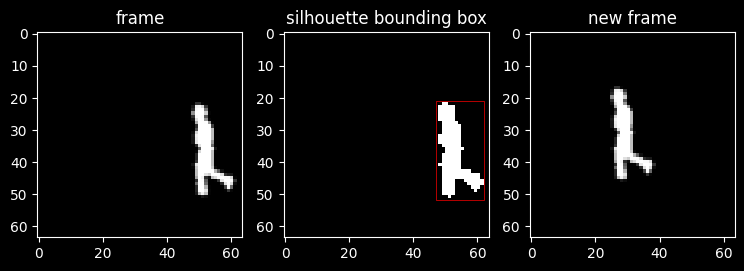

In [39]:
fig, axs = plt.subplots(1, 3, figsize=(3 * 3, 3))


axs[0].imshow(
    example_frame[0],
    cmap='grey',
    vmin=0, vmax=1, 
)
axs[0].set_title('frame')


axs[1].imshow(
    strickt_silhouette,
    cmap='grey',
    vmin=0, vmax=1, 
)
# plot a bounding box
delta = 1
silhouette_rect = patches.Rectangle(
    (x_ids[0] - delta, y_ids[0] - delta), 
    x_ids[-1] - x_ids[0] + 2 * delta, y_ids[-1] - y_ids[0] + 2 * delta, 
    linewidth=0.5, 
    edgecolor='r',
    facecolor='none'
)
axs[1].add_patch(silhouette_rect)
axs[1].set_title('silhouette bounding box')


axs[2].imshow(
    transforms_for_silhouette(silhouette_this),
    cmap='grey',
    vmin=0, vmax=1, 
)
axs[2].set_title('new frame')


plt.show()

### 1.3.2. Exclude cutted (incomplete) silhouettes

In [40]:
EXCLUDE_CUTTED = VARIABLES['exclude_cutted_silhouettes']
# Comment: Some frames are cutted because for some actions a person appears within 
#          a frame and goes to the opposite boundary! 

# Criterias to exclude a frame because of a part of a silhouette is out of frame:
# 1. one of boundaries of a silhouette bounding box coincides with a boundary of a frame;
# 2. if 1^st criteria satisfied and a width of a silhouette bounding box is less than some value
CUTTED_MIN_WIDTH = 15 
# Comment: in fact it is a hyperparameter...

#### Example of a cutted silhouette (if `EXCLUDE_CUTTED == True`)

This process performed within a dataset (see <span style="color:red">Data class</span> below).

In [41]:
# all actions
print(*ACTIONS)

bend jack jump pjump run side skip walk wave1 wave2


In [42]:
# all persons
print(*PERSONS)

daria denis eli ido ira lena lyova moshe shahar


In [43]:
example_act = 'walk'  # select example
example_person = 'moshe'
example_frame_number = 0

example_path = f'{WEIZMANN_DIR}{example_act}_masks/{example_person}_{example_act}.npy'

In [44]:
try:
    example_frame = np.load(example_path)[example_frame_number]
except KeyError:
    print('There is no such file in a train set')

In [45]:
strickt_silhouette = torch.where(torch.tensor(example_frame)[0] > BRIGHTNESS_LIM, 1.0, 0.0)

# find a bounding box for a silhouette
# along y direction
y_ids = torch.where(strickt_silhouette.sum(dim=1) > 0)[0] # indices
# along x direction
x_ids = torch.where(strickt_silhouette.sum(dim=0) > 0)[0] # indices

In [46]:
silhouette_this = torch.tensor(example_frame[0, y_ids[0]:y_ids[-1] + 1, x_ids[0]:x_ids[-1] + 1])
silhouette_this.shape

torch.Size([32, 4])

In [47]:
rect_y = (y_ids[-1] - y_ids[0] + 1).item()
rect_x = (x_ids[-1] - x_ids[0] + 1).item()

assert (silhouette_this.shape[0] == rect_y) and (silhouette_this.shape[1] == rect_x)

In [48]:
# transform selected rectangle to square, centering a silhouette
square_size = CENTERED_MASK_SIZE

# paddings along OY
pad_top_silhouette = int((square_size - rect_y) / 2)
pad_bottom_silhouette = square_size - pad_top_silhouette - rect_y
# paddings along OX
pad_left_silhouette = int((square_size - rect_x) / 2)
pad_right_silhouette = square_size - pad_left_silhouette - rect_x  # params for transforms.Pad

transforms_for_silhouette = transforms.Compose(
  [
      transforms.Pad(
          padding=(
              pad_left_silhouette,  # left padding
              pad_top_silhouette,  # top padding
              pad_right_silhouette,  # right padding
              pad_bottom_silhouette  # bottom padding
          ),
          fill=0,
      ),  # padding to match sizes!
  ]  
)

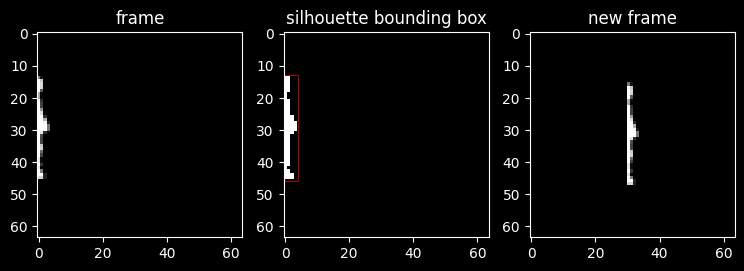

In [49]:
fig, axs = plt.subplots(1, 3, figsize=(3 * 3, 3))


axs[0].imshow(
    example_frame[0],
    cmap='grey',
    vmin=0, vmax=1, 
)
axs[0].set_title('frame')


axs[1].imshow(
    strickt_silhouette,
    cmap='grey',
    vmin=0, vmax=1, 
)
# plot a bounding box
delta = 1
silhouette_rect = patches.Rectangle(
    (x_ids[0] - delta, y_ids[0] - delta), 
    x_ids[-1] - x_ids[0] + 2 * delta, y_ids[-1] - y_ids[0] + 2 * delta, 
    linewidth=0.5, 
    edgecolor='r',
    facecolor='none'
)
axs[1].add_patch(silhouette_rect)
axs[1].set_title('silhouette bounding box')


axs[2].imshow(
    transforms_for_silhouette(silhouette_this),
    cmap='grey',
    vmin=0, vmax=1, 
)
axs[2].set_title('new frame')


plt.show()

In [50]:
print(f'Cutted silhouette width: {x_ids[-1] - x_ids[0]}')

Cutted silhouette width: 3


### 1.3.3. Dataset class

In [51]:
import src.dataset
from src.dataset import WeizmannSeqs

# transfer all constant to module
src.dataset.INIT_MASK_SIZE = INIT_MASK_SIZE
src.dataset.CENTERED_MASK_SIZE = CENTERED_MASK_SIZE

src.dataset.ACTION_TO_ID = ACTION_TO_ID

src.dataset.BRIGHTNESS_LIM = BRIGHTNESS_LIM
src.dataset.CUTTED_MIN_WIDTH = CUTTED_MIN_WIDTH

In [52]:
# dataset of all files (WILL NOT USE IT FURTHER!)
all_seqs_ds = WeizmannSeqs(
    all_files,
    seq_len=SEQ_LEN,
    skip=SKIP,
    augmentation_horizontally_flip=False,  # no horizontal flip!
    exclude_cutted=True,
    centering=True,
)  # item: (sequence, label)

print(
    f"All files subseq (exclude cutted = {VARIABLES['exclude_cutted_silhouettes']}, centered = {VARIABLES['center_silhouettes']}): " +
    f'{len(all_seqs_ds)}'
)

All files subseq (exclude cutted = True, centered = True): 4980


#### Silhouettes height and width statistics

In [53]:
silhouettes_heights = []
silhouettes_widths = []

for filepath in tqdm(all_files):
    file_num_frames = len(all_seqs_ds.files_silhouettes_coord[filepath])
    for ind_frame in range(file_num_frames):
        if all_seqs_ds.files_silhouettes_coord[filepath][ind_frame] is None:  # no silhouette!
            silhouettes_heights.append(0)
            silhouettes_widths.append(0)
            continue
            
        y1, x1, y2, x2 = all_seqs_ds.files_silhouettes_coord[filepath][ind_frame]

        silhouettes_heights.append(y2 - y1)
        silhouettes_widths.append(x2 - x1)

100%|████████████████████████████████████████| 90/90 [00:00<00:00, 62373.99it/s]


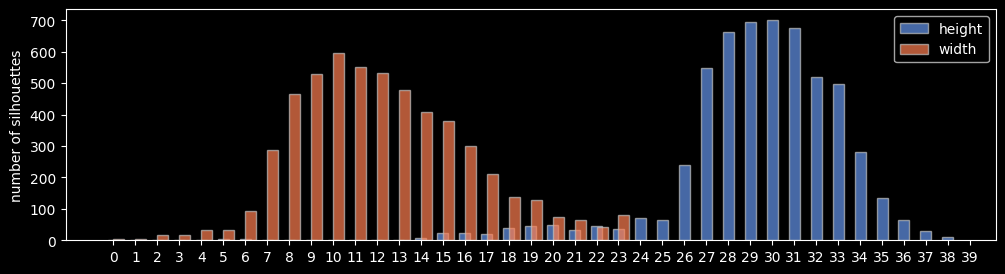

In [54]:
fig, ax0 = plt.subplots(1, 1, figsize=(12, 3))
bars_width = 0.5
bars_shift = 0.25

ax0.hist(
    silhouettes_heights, bins=list(range(40)),
    align='left', rwidth=bars_width, label='height',
    facecolor='cornflowerblue', edgecolor='silver', alpha=0.7
)
ax0.hist(
    np.array(silhouettes_widths) + bars_shift, bins=np.arange(25) + bars_shift,
    align='left', rwidth=bars_width, label='width',
    facecolor='coral', edgecolor='silver', alpha=0.7
)

ax0.set_xticks(range(40))
# ax0.set_xticklabels([ID_TO_ACTION[ind] for ind in range(NUM_ACTIONS)])

ax0.set_ylabel('number of silhouettes')
# ax0.set_ylim([0, 1000])

ax0.legend()
plt.show()

In [55]:
del all_seqs_ds

### 1.3.4. Train and Test datasets of sub-sequences

In [56]:
# if True uses a horisotal flip to make dataset twice as large
AUGMENTATION_FLIP = VARIABLES['augmentation_flip']

In [57]:
AUGMENTATION_FLIP

True

In [58]:
train_seqs_ds = WeizmannSeqs(
    all_train_files,
    seq_len=SEQ_LEN,
    skip=SKIP,
    augmentation_horizontally_flip=AUGMENTATION_FLIP,  # no horizontal flip!
    exclude_cutted=EXCLUDE_CUTTED,
    centering=CENTERING,
)  # item: (sequence, label)

test_seqs_ds = WeizmannSeqs(
    all_test_files,
    seq_len=SEQ_LEN,
    skip=SKIP,
    augmentation_horizontally_flip=AUGMENTATION_FLIP,  # no horizontal flip!
    exclude_cutted=EXCLUDE_CUTTED,
    centering=CENTERING,
)  # item: (sequence, label)

In [59]:
print(f'Train dataset of sequences: {len(train_seqs_ds)}')
print(f'Test  dataset of sequences: {len(test_seqs_ds)}')

Train dataset of sequences: 6896
Test  dataset of sequences: 3064


#### Classes disbalance

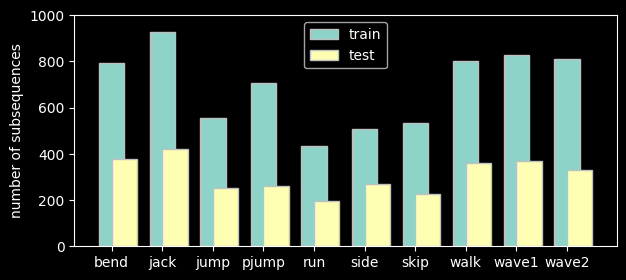

In [60]:
train_list = [ACTION_TO_ID[key] for key, val in train_seqs_ds.seqs_counter.items() for _ in range(val)]
test_list = [ACTION_TO_ID[key] for key, val in test_seqs_ds.seqs_counter.items() for _ in range(val)]


fig, ax0 = plt.subplots(1, 1, figsize=(7, 3))
bars_width = 0.5
bars_shift = 0.25

ax0.hist(
    train_list, bins=list(range(NUM_ACTIONS + 1)),
    align='left', rwidth=bars_width, label='train',
    edgecolor='silver'
)
ax0.hist(
    np.array(test_list) + bars_shift, bins=np.arange(NUM_ACTIONS + 1) + bars_shift,
    align='left', rwidth=bars_width, label='test',
    edgecolor='silver'
)

ax0.set_xticks(range(NUM_ACTIONS))
ax0.set_xticklabels([ID_TO_ACTION[ind] for ind in range(NUM_ACTIONS)])

ax0.set_ylabel('number of subsequences')
ax0.set_ylim([0, 1000])

ax0.legend()
plt.show()

#### Weights of classes (based on train dataset)

In [61]:
WEIGHTED_CLASSES = VARIABLES['weighted_classes']  # if we need to use weights for classes to balance

In [62]:
if WEIGHTED_CLASSES:
    max_class_size = max(train_seqs_ds.seqs_counter.values())
    
    weights_dict = {
        key: max_class_size / value 
        for key, value in train_seqs_ds.seqs_counter.items()
    }

In [63]:
if WEIGHTED_CLASSES:
    WEIGHTS_DICT = weights_dict

    for key, val in weights_dict.items():
        print(f'{key}\t:\t{val}')

bend	:	1.1717171717171717
jack	:	1.0
jump	:	1.669064748201439
pjump	:	1.3144475920679888
run	:	2.1481481481481484
side	:	1.8339920948616601
skip	:	1.7378277153558053
walk	:	1.1571072319201996
wave1	:	1.1180722891566266
wave2	:	1.145679012345679


**<span style="color:red">TODO:</span>** How to use weights? 


### 1.3.5. Examples of sequences from Train dataset

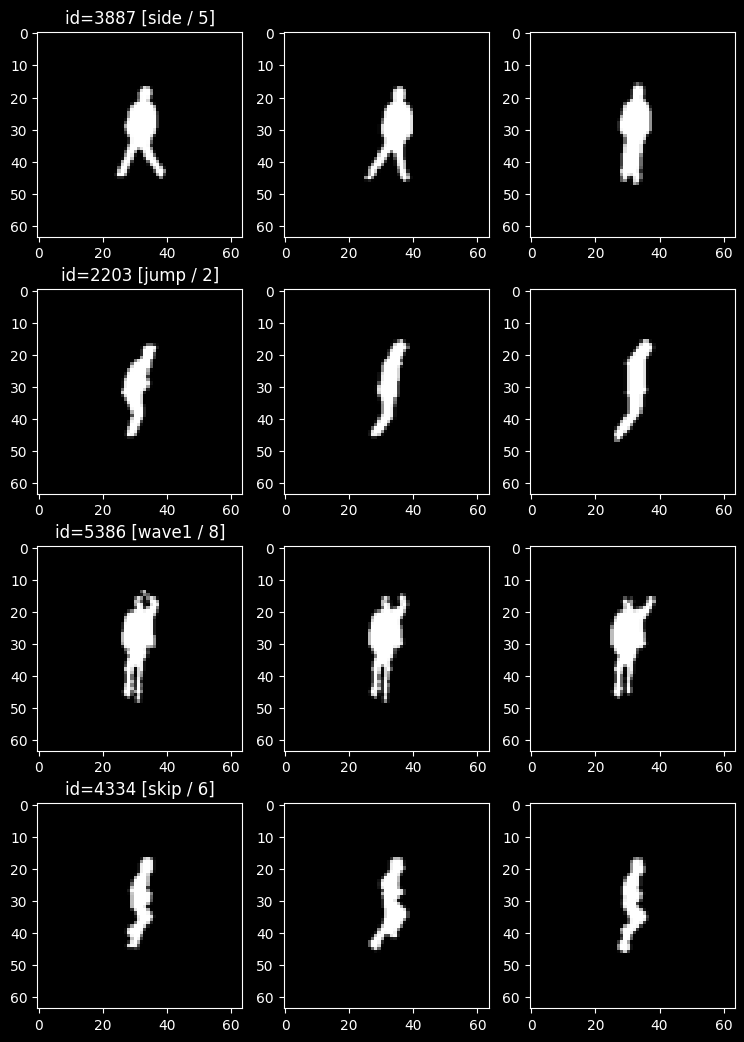

In [64]:
# plot several EXAMPLES from TRAIN dataset
n_examples = 4  # number of examples to plot
# choosing indecies of images (from train) to plot
random.seed(12)
train_examples_ids = random.sample(range(len(train_seqs_ds)), n_examples)

n_cols = SEQ_LEN  # number of columns to plot masks (last column for targets)
cmap = 'grey'

fig, axs = plt.subplots(n_examples, n_cols, figsize=(n_cols * 3, n_examples * 3.2))

for ind_ex, ind_train in enumerate(train_examples_ids):
    sequence, label = train_seqs_ds[ind_train]
    
    for frame_ind in range(SEQ_LEN):
        frame_this = sequence[frame_ind]
        
        assert isinstance(frame_this, torch.Tensor)
        
        if frame_ind == 0:
            axs[ind_ex][frame_ind].set_title(f'id={ind_train} [{ID_TO_ACTION[label]} / {label}]')

        axs[ind_ex][frame_ind].imshow(
            frame_this[0], cmap=cmap,
            vmin=0, vmax=1, 
        )
    
plt.show()

# 3. Neural Network

## 3.1. Network architecture

### 3.1.1. Convolutional encoder

In [65]:
CHANNELS_1 = 4
CHANNELS_2 = 8  # hyperparameters

In [66]:
POOL_SIZE = 2

In [67]:
class CNNEncoder(nn.Module):
    
    def __init__(self, feature_dim, input_size=(1, INIT_MASK_SIZE, INIT_MASK_SIZE)):
        super(CNNEncoder, self).__init__()
        C, H, W = input_size

        self.conv = nn.Sequential(
            nn.Conv2d(C, CHANNELS_1, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(POOL_SIZE),
            nn.Conv2d(CHANNELS_1, CHANNELS_2, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(POOL_SIZE),
        )

        # Calculate the size after conv layers dynamically
        with torch.no_grad():
            dummy_input = torch.zeros(1, C, H, W)
            conv_output = self.conv(dummy_input)
            conv_out_dim = conv_output.view(1, -1).size(1)

        self.fc = nn.Linear(conv_out_dim, feature_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)  # make a vector
        x = self.fc(x)
        return x

### 3.1.2. Our network

It includes a convolutional encoder and a LSTM layer!

In [68]:
FEATURE_DIM = VARIABLES['feature_dim']
HIDDEN_DIM = VARIABLES['hidden_dim']  # hyperparameters

In [69]:
class ConvRecClassifier(nn.Module):
    def __init__(
        self, 
        feature_dim=FEATURE_DIM,  # number of features after a convolutional encoder
        hidden_dim=HIDDEN_DIM, 
        num_classes=NUM_ACTIONS, 
        input_size=(1, INIT_MASK_SIZE, INIT_MASK_SIZE)
    ):
        super(ConvRecClassifier, self).__init__()
        self.cnn_encoder = CNNEncoder(feature_dim, input_size=input_size)
        self.lstm = nn.LSTM(input_size=feature_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x_seq):
        # x_seq: (batch_size, seq_len, C, H, W)
        batch_size, seq_len, C, H, W = x_seq.shape
        # encoding
        x_seq = x_seq.view(batch_size * seq_len, C, H, W)
        features = self.cnn_encoder(x_seq)  # (batch_size * seq_len, feature_dim)
        features = features.view(batch_size, seq_len, -1)  # (batch_size, seq_len, feature_dim)
        # recurrent part
        lstm_out, _ = self.lstm(features)
        last_hidden = lstm_out[:, -1, :]
        # final layer
        out = self.fc(last_hidden)
        return out

## 3.3. Necessary things for future training

### 3.3.1. Loss function and optimizer

In [70]:
loss_func_clf = nn.CrossEntropyLoss()
loss_func_name = 'CE loss'

In [71]:
LR = VARIABLES['adam_lr']

In [72]:
def get_adam_optimizer(net):
    return torch.optim.Adam(
        params=net.parameters(),  # NETWORK PARAMETERS!
        lr=LR
    )

### 3.3.2. Data loaders

In [73]:
train_bs = VARIABLES['train_batch_size']  # a batch size for training set
val_bs = VARIABLES['val_batch_size']

In [74]:
train_dataloader = torch.utils.data.DataLoader(
    train_seqs_ds,
    batch_size=train_bs,
    shuffle=True,
    drop_last=False,
)

test_dataloader = torch.utils.data.DataLoader(
    test_seqs_ds,
    batch_size=val_bs,
    shuffle=True,
    drop_last=False,
)

### 3.3.3. Metrics before training

In [75]:
nn_no_train = ConvRecClassifier()

In [76]:
test_losses_0, _, test_accuracy_0 = val_loop(
    nn_no_train,
    test_dataloader,
    loss_func_clf,
    show_process=True,
)  # evaluate the model

print(
    'Results before training on TEST set:\n' + 
    f'\t{loss_func_name} : {np.mean(test_losses_0):.6f}\n' +
    f'\tAccuracy : {(test_accuracy_0*100):>0.1f} %'
)

validation: 100%|████████████████████████████| 154/154 [00:00<00:00, 181.32it/s]

Results before training on TEST set:
	CE loss : 2.315761
	Accuracy : 8.2 %


# 4. Network Training

#### Parameters

In [77]:
n_epochs = VARIABLES['number_of_epochs']
print_each = 1  # print each n'th epoch info

#### Network and optimizer init

In [78]:
nn_to_train = ConvRecClassifier()

optimizer_clf = get_adam_optimizer(nn_to_train)

In [79]:
scheduler = None  # sheduler for a lr tuning during training 

#### Learning

In [80]:
train_epochs_losses = []
val_epochs_losses = []  # to store losses of each epoch

train_epochs_acc = []
val_epochs_acc = []  # to store accuracies

torch.manual_seed(98)  # for reproducability

for epoch in range(n_epochs):
    if (epoch == 0) or ((epoch + 1) % print_each == 0) or (epoch == n_epochs - 1):
        print(f'Epoch #{epoch + 1}: ', end='')
        show_progress = True
    else:
        show_progress = False

    # TRAIN
    start_train_time = time.time()  # start time of the epoch (train)
    train_losses, _, train_accuracy = train_loop(
        nn_to_train,  # optical network composed in 3.
        train_dataloader,  # dataloader of training set
        loss_func_clf,
        optimizer_clf,
        show_process=show_progress,
    )  # train the model
    mean_train_loss = np.mean(train_losses)
    
    if (epoch == 0) or ((epoch + 1) % print_each == 0) or (epoch == n_epochs - 1):  # train info
        print('Training results')
        print(f'\t{loss_func_name} : {mean_train_loss:.6f}')
        print(f'\tAccuracy : {(train_accuracy*100):>0.1f} %')
        print(f'\t------------   {time.time() - start_train_time:.2f} s')

    # VALIDATION
    start_val_time = time.time()  # start time of the epoch (validation)
    val_losses, _, val_accuracy = val_loop(
        nn_to_train,  # optical network composed in 3.
        test_dataloader,  # dataloader of validation set
        loss_func_clf,
        show_process=show_progress,
    )  # evaluate the model
    mean_val_loss = np.mean(val_losses)
    
    if (epoch == 0) or ((epoch + 1) % print_each == 0) or (epoch == n_epochs - 1):  # validation info
        print('Validation results')
        print(f'\t{loss_func_name} : {mean_val_loss:.6f}')
        print(f'\tAccuracy : {(val_accuracy*100):>0.1f} %')
        print(f'\t------------   {time.time() - start_val_time:.2f} s')
            
    if scheduler:
        scheduler.step(mean_val_loss)

    # save losses
    train_epochs_losses.append(mean_train_loss)
    val_epochs_losses.append(mean_val_loss)
    # seve ac curacies
    train_epochs_acc.append(train_accuracy)
    val_epochs_acc.append(val_accuracy)

Epoch #1: 

train: 100%|█████████████████████████████████| 690/690 [00:05<00:00, 115.42it/s]


Training results
	CE loss : 1.243518
	Accuracy : 63.9 %
	------------   5.98 s


validation: 100%|████████████████████████████| 154/154 [00:00<00:00, 217.60it/s]


Validation results
	CE loss : 0.827054
	Accuracy : 74.5 %
	------------   0.71 s
Epoch #2: 

...

Validation results
	CE loss : 0.641851
	Accuracy : 85.5 %
	------------   0.68 s
Epoch #10: 

train: 100%|█████████████████████████████████| 690/690 [00:05<00:00, 117.46it/s]


Training results
	CE loss : 0.008798
	Accuracy : 99.9 %
	------------   5.88 s


validation: 100%|████████████████████████████| 154/154 [00:00<00:00, 193.75it/s]

Validation results
	CE loss : 0.643059
	Accuracy : 85.4 %
	------------   0.80 s


#### Learning curves

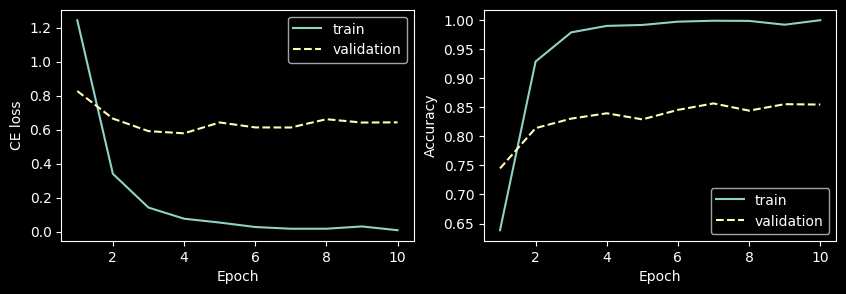

In [81]:
# learning curve
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

axs[0].plot(range(1, n_epochs + 1), np.array(train_epochs_losses), label='train')
axs[0].plot(range(1, n_epochs + 1), np.array(val_epochs_losses), linestyle='dashed', label='validation')

axs[1].plot(range(1, n_epochs + 1), train_epochs_acc, label='train')
axs[1].plot(range(1, n_epochs + 1), val_epochs_acc, linestyle='dashed', label='validation')

axs[0].set_ylabel(loss_func_name)
axs[0].set_xlabel('Epoch')
axs[0].legend()

axs[1].set_ylabel('Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].legend()

plt.show()

#### Saving results

In [82]:
# array with all losses
all_lasses_header = ','.join([
    f'{loss_func_name.split()[0]}_train', f'{loss_func_name.split()[0]}_val',
    'accuracy_train', 'accuracy_val'
])
all_losses_array = np.array(
    [train_epochs_losses, val_epochs_losses, train_epochs_acc, val_epochs_acc]
).T

In [83]:
# filepath to save the model
model_filepath = f'{RESULTS_FOLDER}/recurrent_net.pth'
# filepath to save losses
losses_filepath = f'{RESULTS_FOLDER}/training_curves.csv'

In [85]:
# saving model
torch.save(nn_to_train.state_dict(), model_filepath)

In [86]:
# saving losses
np.savetxt(
    losses_filepath, all_losses_array,
    delimiter=',', header=all_lasses_header, comments=""
)